In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os



In [2]:
sys.path.append(os.path.abspath(".."))

In [3]:
from src.data_utils import (load_data)
from src.eda_utils import (
    data_structure,
    data_types,
    show_full_dataframe,
    full_summary,
    data_quality_report,
    check_numerical_anomalies,
    check_categorical_anomalies,
    check_placeholder_values,
    plot_numeric_distributions,
    plot_categorical_counts,
    plot_target_distribution,
    plot_feature_vs_target,
    skewness_report,
    outlier_overview
)
from src.cleaning_utils import (to_category)


# BEFORE CLEANING

In [4]:
X_train = load_data("../data/X_train.csv")
y_train = load_data("../data/y_train.csv")

df_raw = X_train.merge(y_train, on="id")

DataFrame successfully loaded.
Shape: (59400, 40)
DataFrame successfully loaded.
Shape: (59400, 2)


In [5]:
data_structure(df_raw)

 Shape: (59400, 41)

 Columns:
['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer', 'longitude', 'latitude', 'wpt_name', 'num_private', 'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga', 'ward', 'population', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'construction_year', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group', 'status_group']


In [6]:
data_types(df_raw)

 Data Types:
id                         int64
amount_tsh               float64
date_recorded                str
funder                       str
gps_height                 int64
installer                    str
longitude                float64
latitude                 float64
wpt_name                     str
num_private                int64
basin                        str
subvillage                   str
region                       str
region_code                int64
district_code              int64
lga                          str
ward                         str
population                 int64
public_meeting            object
recorded_by                  str
scheme_management            str
scheme_name                  str
permit                    object
construction_year          int64
extraction_type              str
extraction_type_group        str
extraction_type_class        str
management                   str
management_group             str
payment                      s

In [7]:
show_full_dataframe(df_raw)

      id  amount_tsh date_recorded        funder  gps_height     installer  longitude   latitude              wpt_name  num_private                    basin  subvillage   region  region_code  \
0  69572      6000.0    2011-03-14         Roman        1390         Roman  34.938093  -9.856322                  none            0               Lake Nyasa    Mnyusi B   Iringa           11   
1   8776         0.0    2013-03-06       Grumeti        1399       GRUMETI  34.698766  -2.147466              Zahanati            0            Lake Victoria     Nyamara     Mara           20   
2  34310        25.0    2013-02-25  Lottery Club         686  World vision  37.460664  -3.821329           Kwa Mahundi            0                  Pangani     Majengo  Manyara           21   
3  67743         0.0    2013-01-28        Unicef         263        UNICEF  38.486161 -11.155298  Zahanati Ya Nanyumbu            0  Ruvuma / Southern Coast  Mahakamani   Mtwara           90   
4  19728         0.0    2011-0

In [8]:
full_summary(df_raw)


Numeric Summary:
                 id     amount_tsh    gps_height     longitude      latitude  \
count  59400.000000   59400.000000  59400.000000  59400.000000  5.940000e+04   
mean   37115.131768     317.650385    668.297239     34.077427 -5.706033e+00   
std    21453.128371    2997.574558    693.116350      6.567432  2.946019e+00   
min        0.000000       0.000000    -90.000000      0.000000 -1.164944e+01   
25%    18519.750000       0.000000      0.000000     33.090347 -8.540621e+00   
50%    37061.500000       0.000000    369.000000     34.908743 -5.021597e+00   
75%    55656.500000      20.000000   1319.250000     37.178387 -3.326156e+00   
max    74247.000000  350000.000000   2770.000000     40.345193 -2.000000e-08   

        num_private   region_code  district_code    population  \
count  59400.000000  59400.000000   59400.000000  59400.000000   
mean       0.474141     15.297003       5.629747    179.909983   
std       12.236230     17.587406       9.633649    471.482176  

In [9]:
data_quality_report(df_raw)


 Missing Values Report:
                       missing_values  percentage
scheme_name                     28810   48.501684
scheme_management                3878    6.528620
installer                        3655    6.153199
funder                           3637    6.122896
public_meeting                   3334    5.612795
permit                           3056    5.144781
subvillage                        371    0.624579
wpt_name                            2    0.003367
id                                  0    0.000000
latitude                            0    0.000000
longitude                           0    0.000000
date_recorded                       0    0.000000
gps_height                          0    0.000000
amount_tsh                          0    0.000000
num_private                         0    0.000000
basin                               0    0.000000
region                              0    0.000000
ward                                0    0.000000
lga                       

In [10]:
check_numerical_anomalies(df_raw)

 Numerical Anomalies:
{}


{}

In [11]:
check_categorical_anomalies(df_raw)

 Categorical Anomalies (with counts):
{'funder': {'0': 777}, 'installer': {'0': 777}, 'wpt_name': {'24': 1}, 'subvillage': {'1': 132, '19': 3, '44': 3, '54': 2, '45': 1, '63': 1, '18': 1, '62': 1, '60': 1, '49': 1, '43': 1, '20': 1, '42': 1, '48': 1, '47': 1, '30': 1, '24': 1}}


{'funder': {'0': 777},
 'installer': {'0': 777},
 'wpt_name': {'24': 1},
 'subvillage': {'1': 132,
  '19': 3,
  '44': 3,
  '54': 2,
  '45': 1,
  '63': 1,
  '18': 1,
  '62': 1,
  '60': 1,
  '49': 1,
  '43': 1,
  '20': 1,
  '42': 1,
  '48': 1,
  '47': 1,
  '30': 1,
  '24': 1}}

In [12]:
check_placeholder_values(df_raw)

 Placeholder Values Found:
{'funder': {'0': 777, 'Unknown': 4}, 'installer': {'0': 777, 'Unknown': 3, 'unknown': 1}, 'wpt_name': {'none': 3563, 'Unknown': 3}, 'scheme_name': {'none': 25}, 'management': {'unknown': 561}, 'management_group': {'unknown': 561}, 'payment': {'unknown': 8157}, 'payment_type': {'unknown': 8157}, 'water_quality': {'unknown': 1876}, 'quality_group': {'unknown': 1876}, 'quantity': {'unknown': 789}, 'quantity_group': {'unknown': 789}, 'source': {'unknown': 66}, 'source_class': {'unknown': 278}}


{'funder': {'0': 777, 'Unknown': 4},
 'installer': {'0': 777, 'Unknown': 3, 'unknown': 1},
 'wpt_name': {'none': 3563, 'Unknown': 3},
 'scheme_name': {'none': 25},
 'management': {'unknown': 561},
 'management_group': {'unknown': 561},
 'payment': {'unknown': 8157},
 'payment_type': {'unknown': 8157},
 'water_quality': {'unknown': 1876},
 'quality_group': {'unknown': 1876},
 'quantity': {'unknown': 789},
 'quantity_group': {'unknown': 789},
 'source': {'unknown': 66},
 'source_class': {'unknown': 278}}

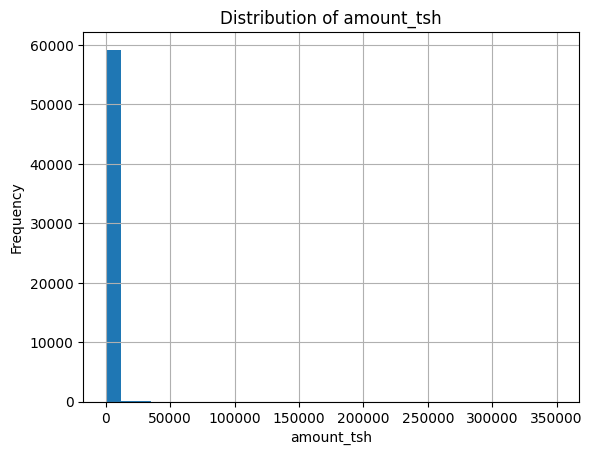

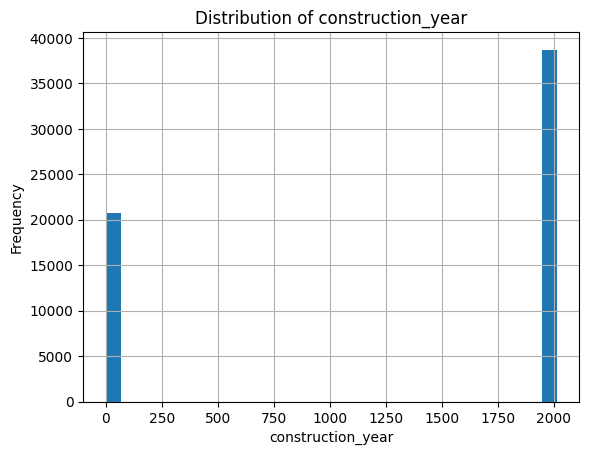

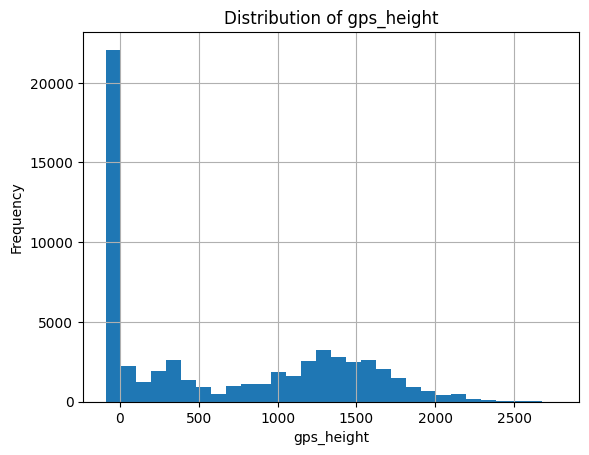

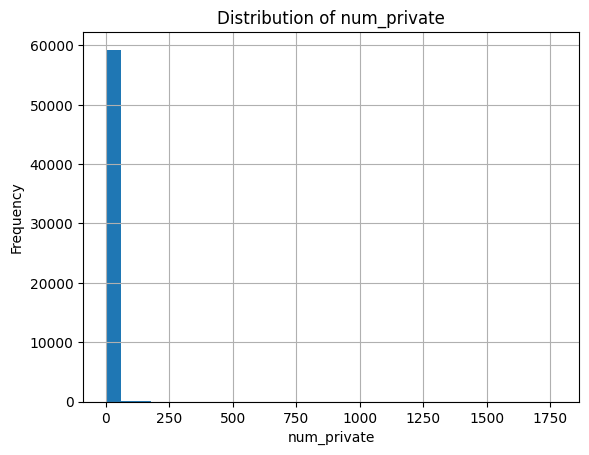

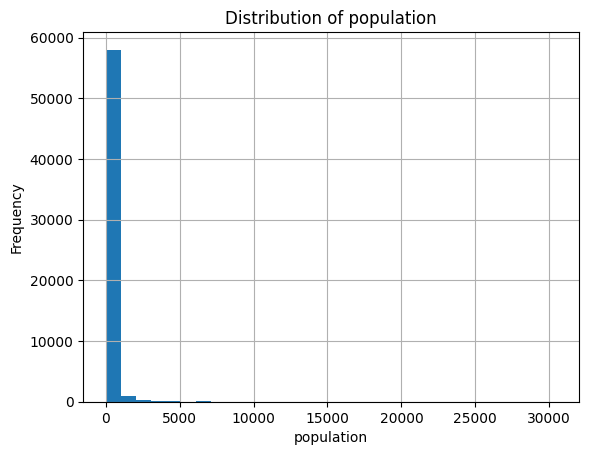

In [13]:
plot_numeric_distributions(df_raw)


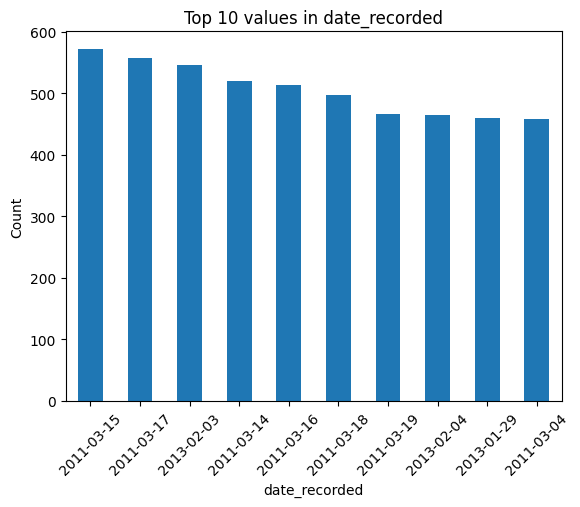

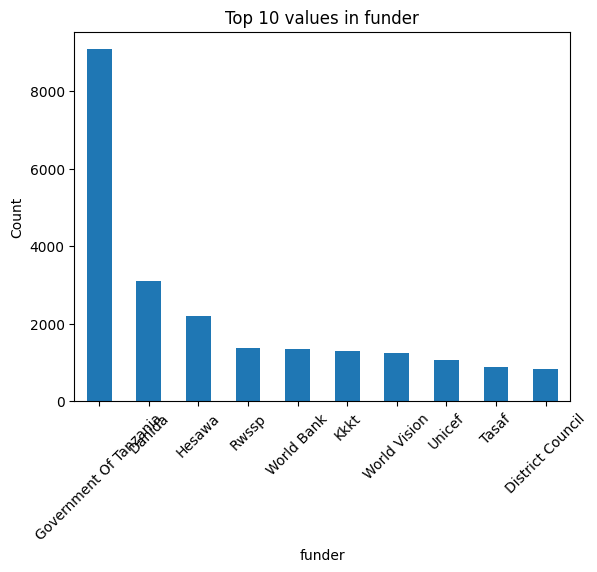

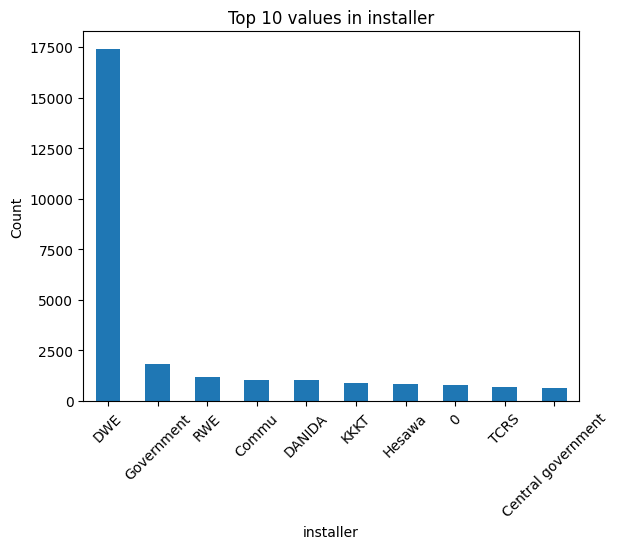

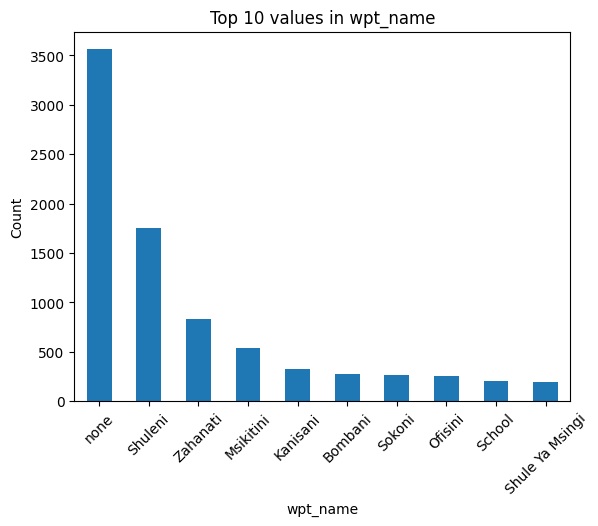

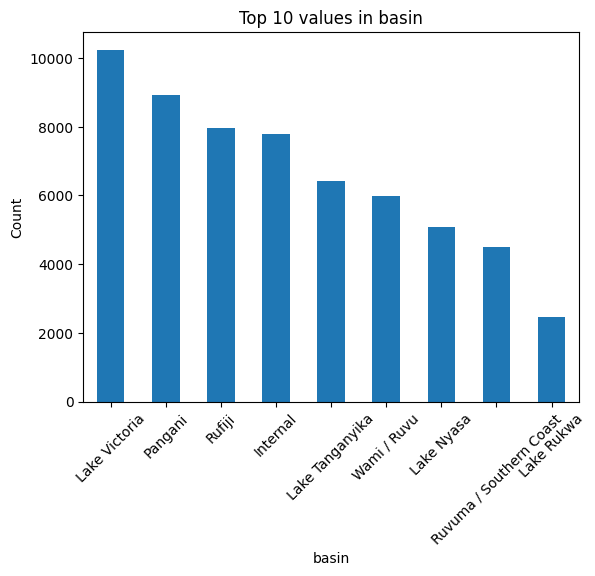

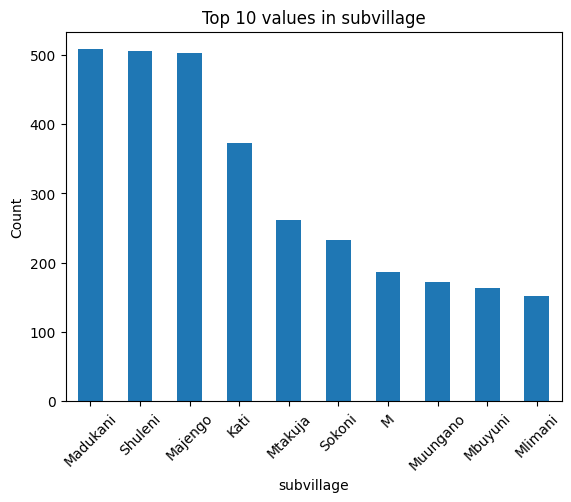

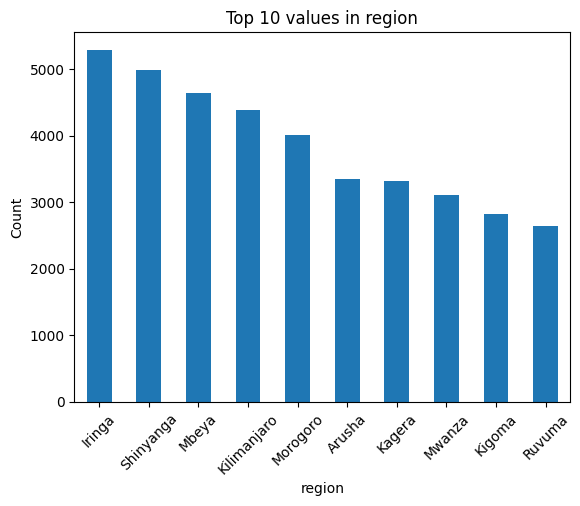

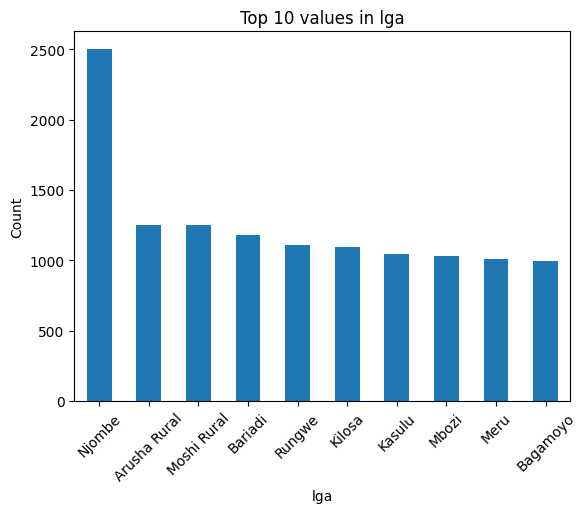

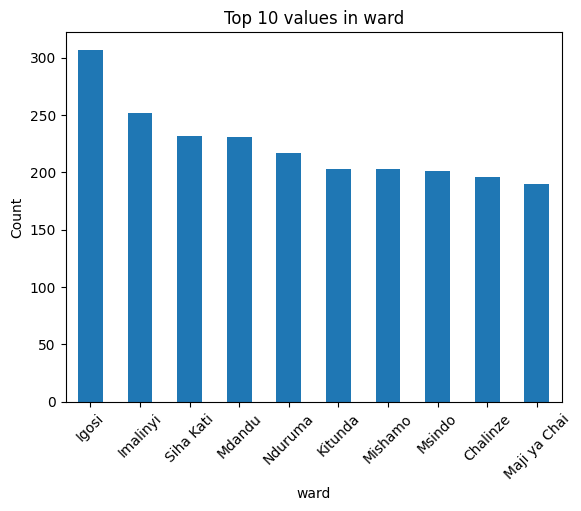

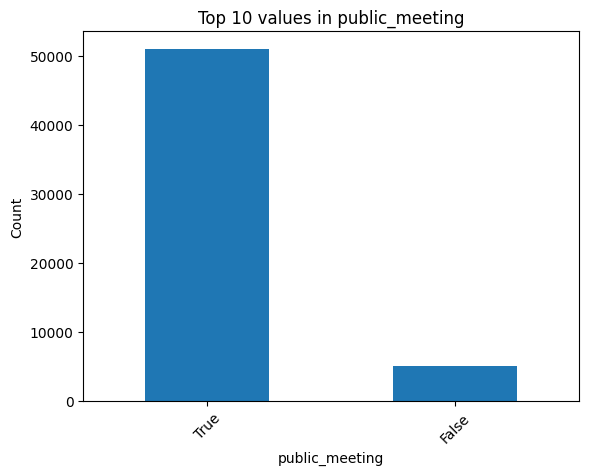

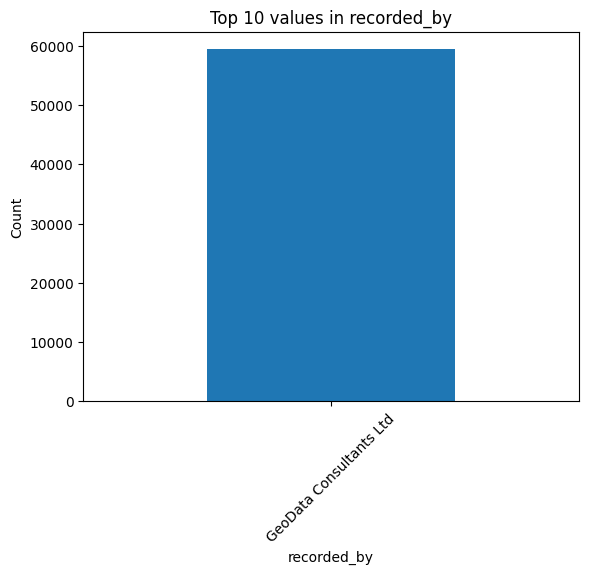

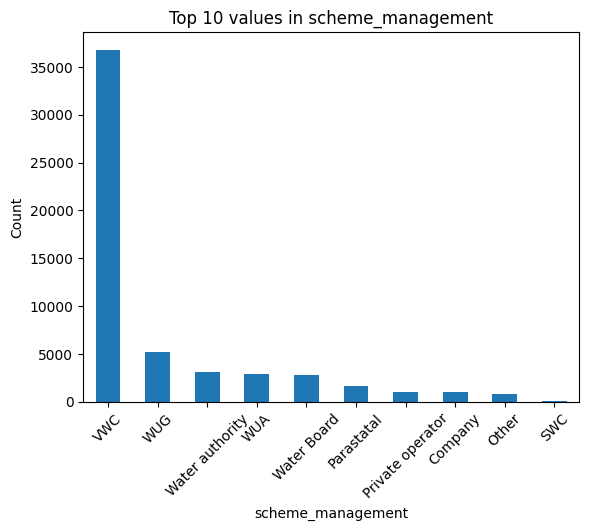

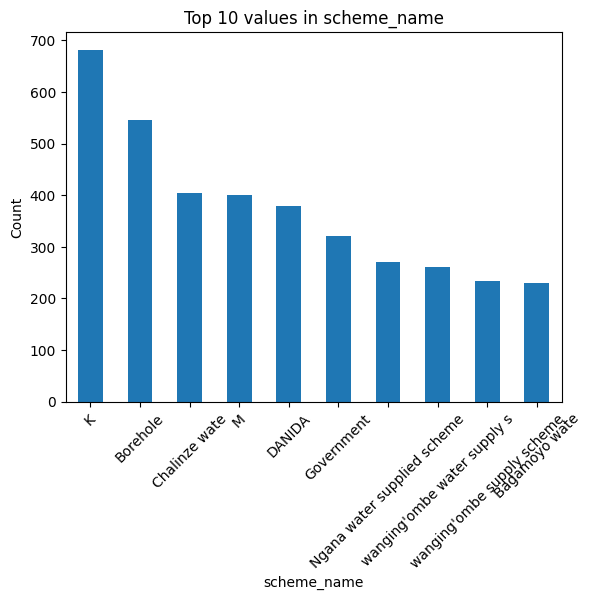

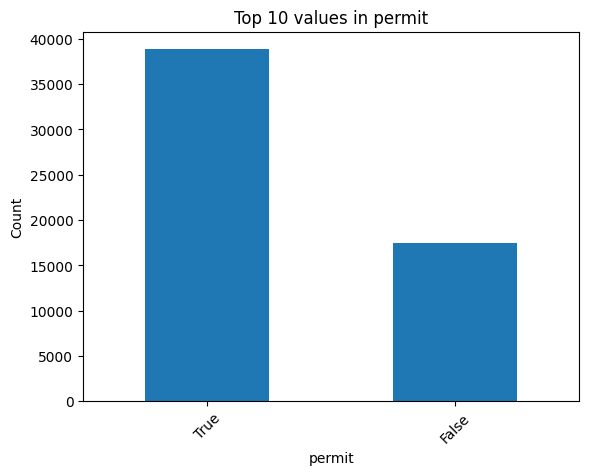

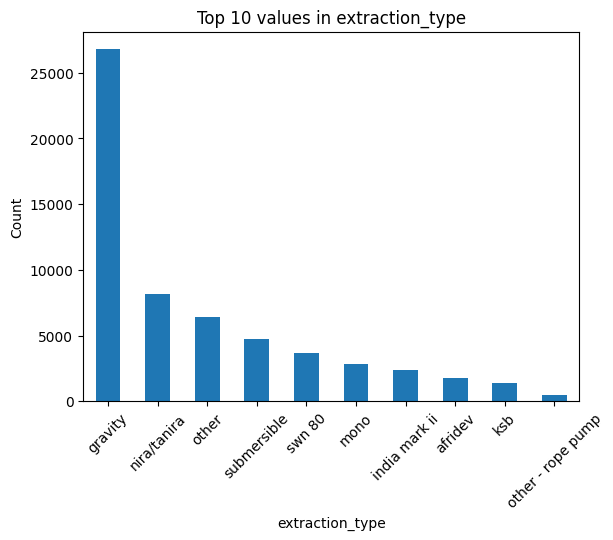

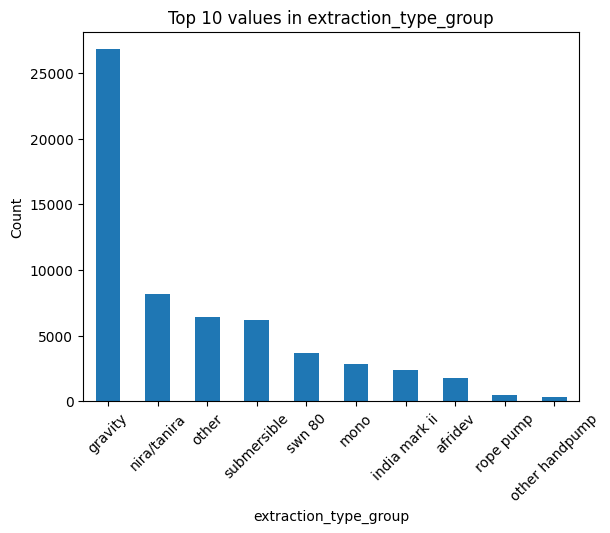

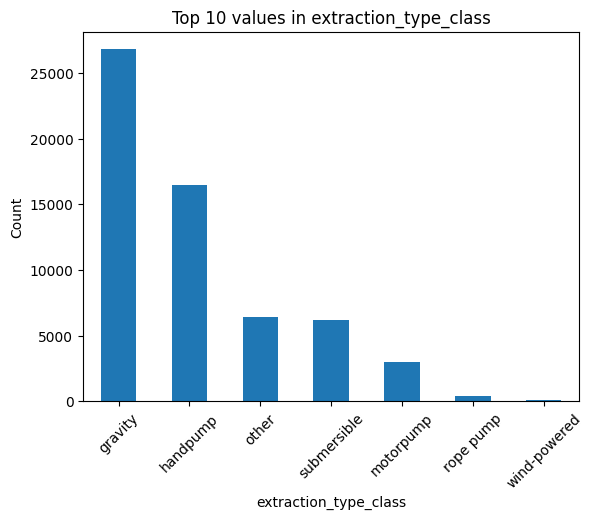

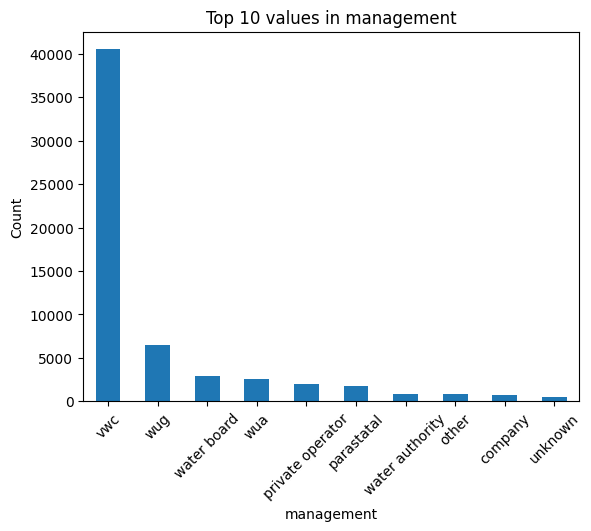

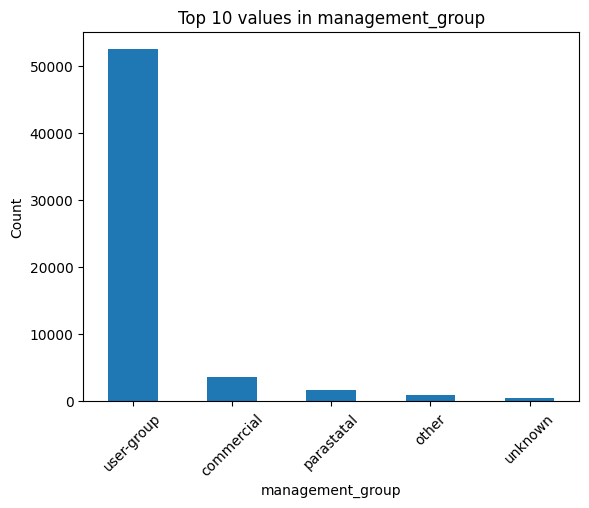

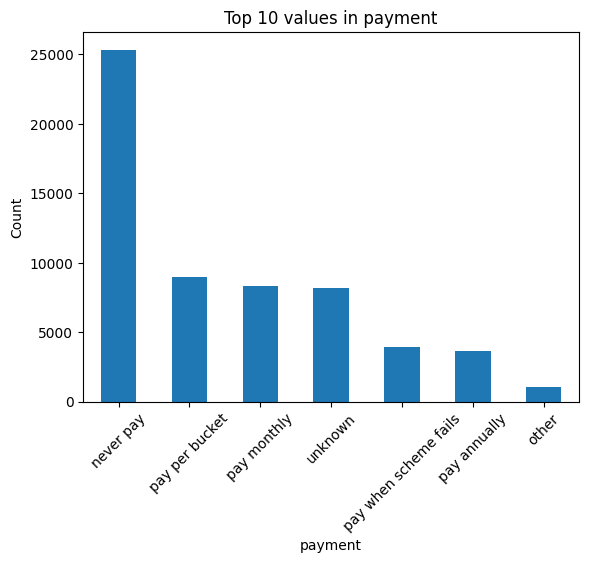

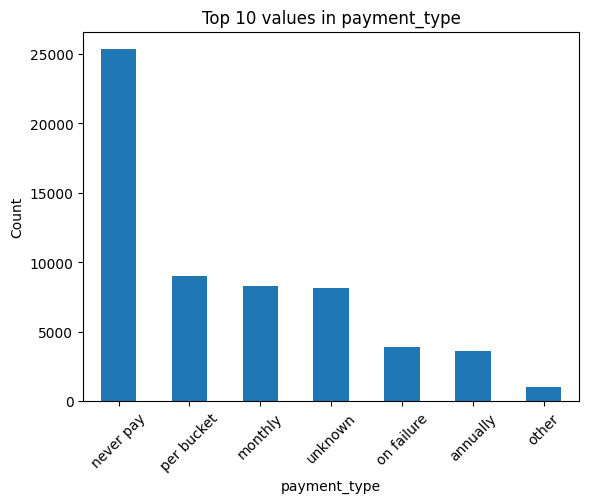

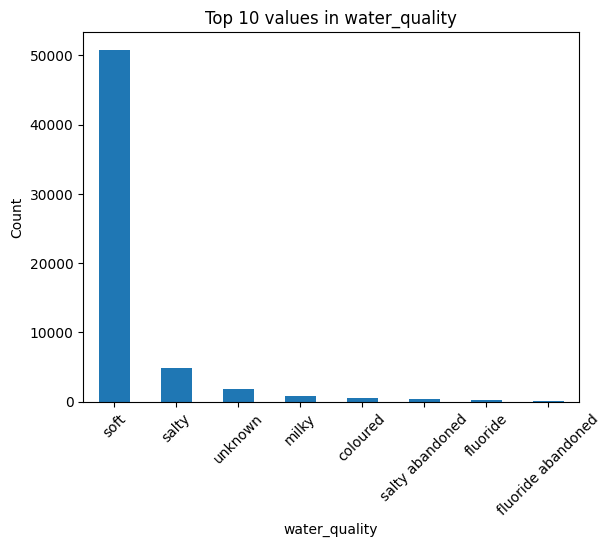

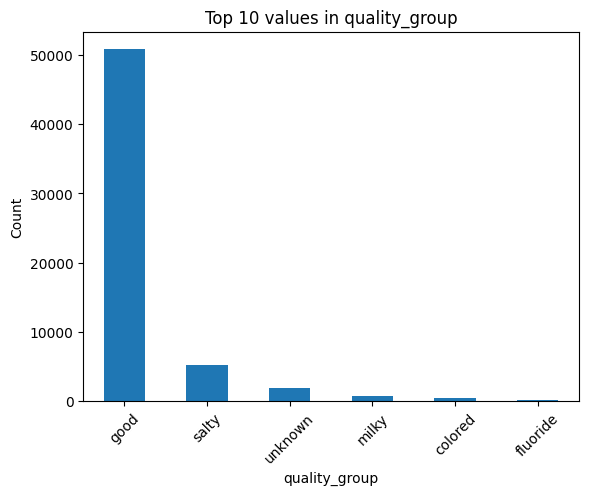

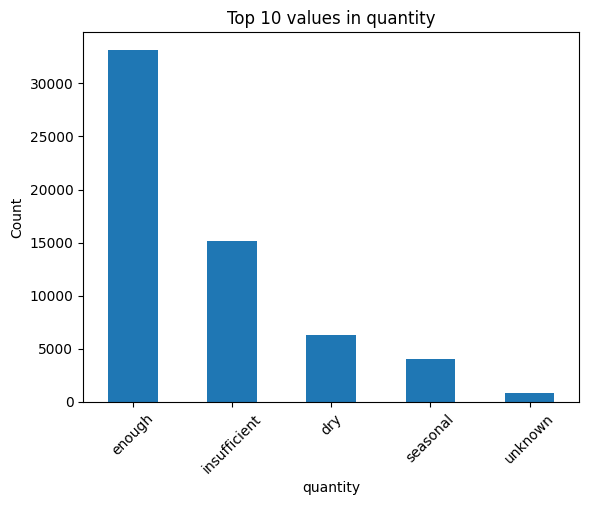

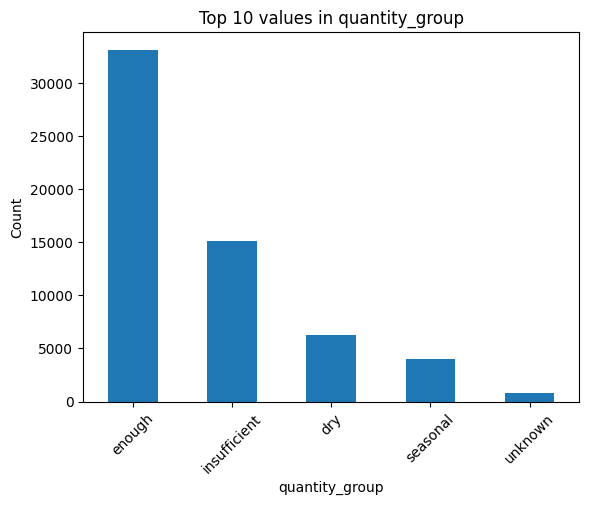

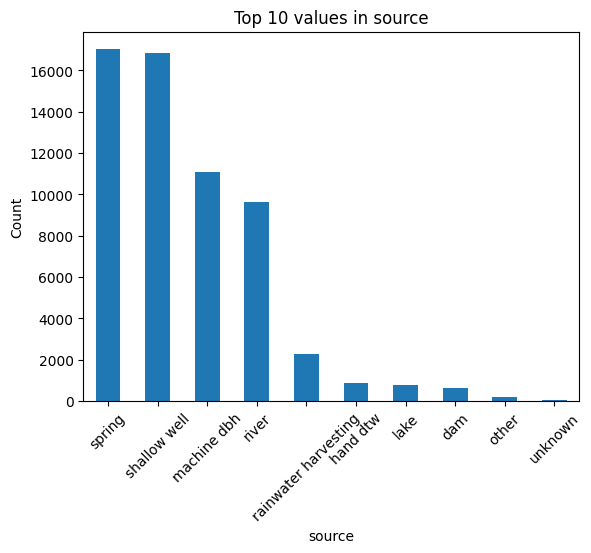

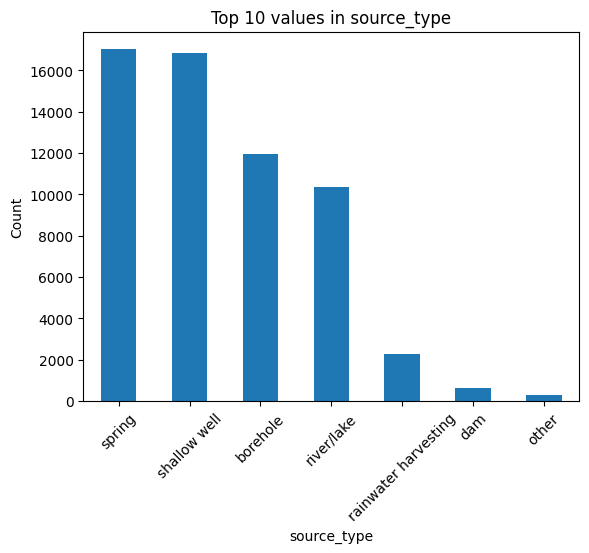

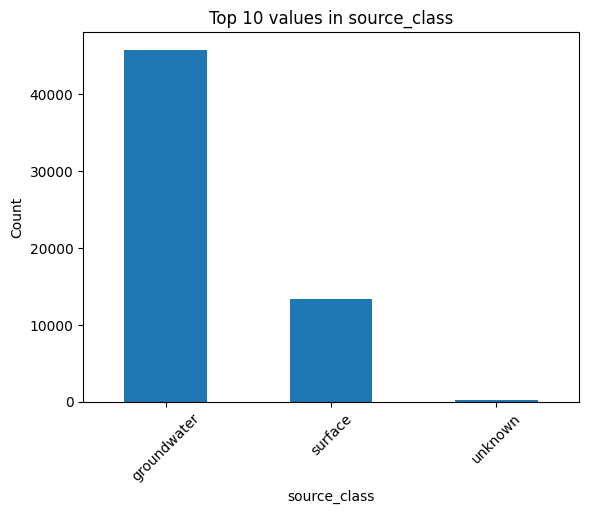

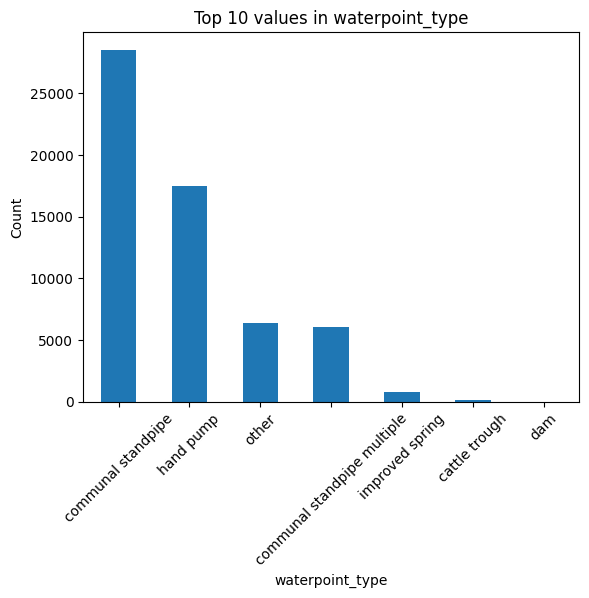

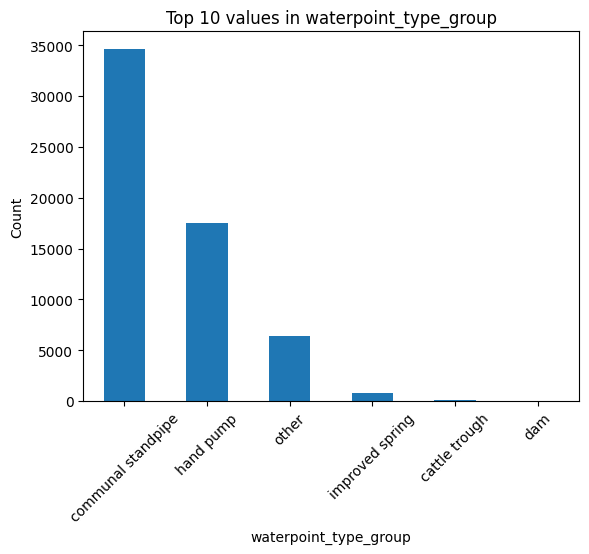

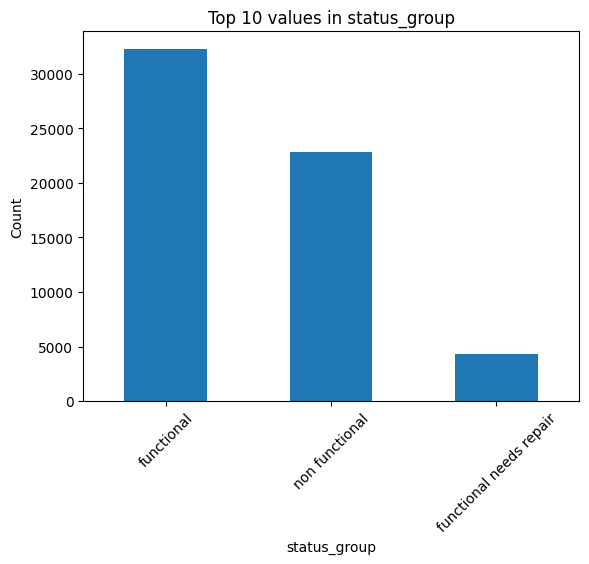

In [14]:
plot_categorical_counts(df_raw)


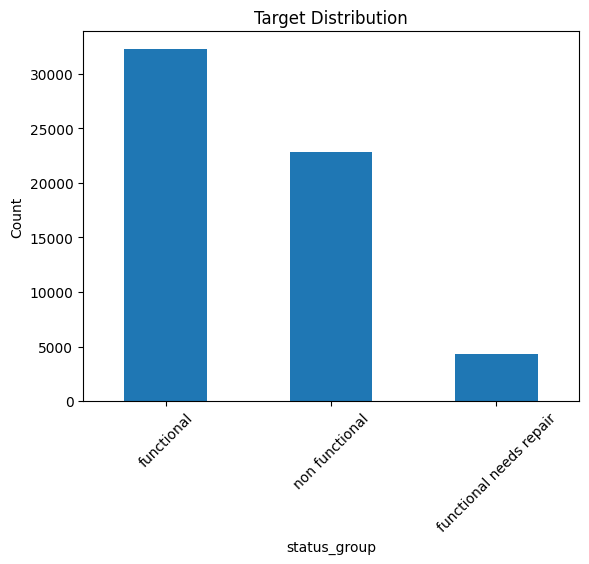

In [15]:
plot_target_distribution(df_raw, "status_group")


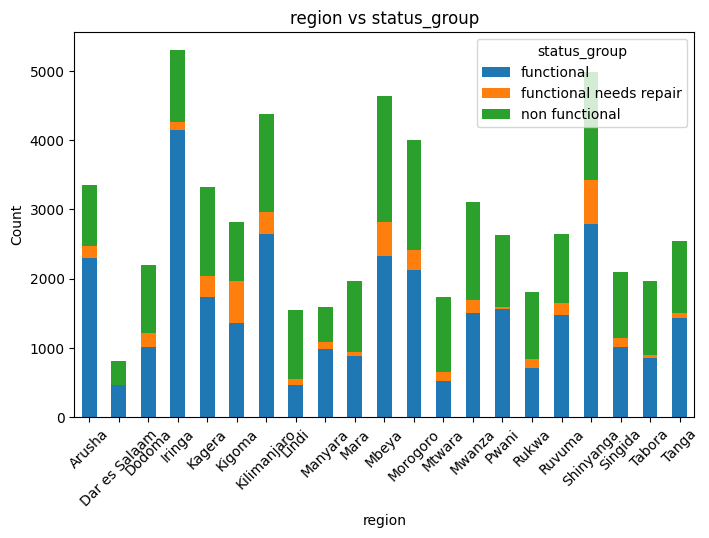

In [16]:
plot_feature_vs_target(df_raw, "region", "status_group")


In [17]:
df_raw.skew(numeric_only=True).sort_values(ascending=False)

num_private          91.933750
amount_tsh           57.807800
population           12.660714
district_code         3.962045
region_code           3.173818
gps_height            0.462402
id                    0.002623
latitude             -0.152037
construction_year    -0.634928
longitude            -4.191046
dtype: float64

In [18]:
skewness_report(df_raw, exclude_cols=["longitude", "latitude", "id", "region_code", "district_code"], threshold=1)

📊 Skewness Report:
                   skewness status
num_private           91.93   High
amount_tsh            57.81   High
population            12.66   High
gps_height             0.46     OK
construction_year     -0.63     OK


,skewness,status
num_private,91.93,High
amount_tsh,57.81,High
population,12.66,High
gps_height,0.46,OK
construction_year,-0.63,OK


In [19]:
outlier_overview(df_raw, exclude_cols=['region_code', 'district_code','id', 'latitude', 'longitude'])

 Simple Outlier Overview:
              column  outliers  percentage (%)  severity
0         amount_tsh     11161           18.79      High
4         population      4383            7.38  Moderate
3        num_private       757            1.27       Low
2         gps_height         0            0.00       Low
1  construction_year         0            0.00       Low


,column,outliers,percentage (%),severity
0,amount_tsh,11161,18.79,High
4,population,4383,7.38,Moderate
3,num_private,757,1.27,Low
2,gps_height,0,0.00,Low
1,construction_year,0,0.00,Low


# FINDINGS

Summary of what we learnt from the raw data and what we intend to do

The raw dataset started with 59,400 rows and 41 columns after merging X_train and y_train, and it contained several missing values, placeholder strings, inconsistent categories, and obvious data quality issues. After cleaning, the dataset was reduced to 58,866 rows and 31 columns, meaning some rows and several redundant or low-value variables were removed during preprocessing.

Main cleaning actions
Missing values were identified in key categorical fields such as schemename, schememanagement, installer, funder, publicmeeting, permit, and payment.

Placeholder categories like 0, Unknown, unknown, and none were standardized to make categorical analysis more reliable.

regioncode and districtcode were converted to categorical type, which is better for grouping and modeling than treating them as numeric quantities.

Duplicate or less useful columns were removed, and the final cleaned dataset kept the core explanatory variables needed for EDA and modeling.

Quality improvement
The raw data showed strong skewness and outliers in variables such as amounttsh, population, and numprivate, with amounttsh being the most problematic. In the cleaned data, the structure became more stable: missing values were eliminated, placeholder noise was reduced, and outlier severity was much lower for the remaining numeric variables.

Final insight
In short, the notebook transformed the dataset from a messy, partially incomplete raw table into a cleaner modeling-ready dataset by standardizing categories, handling placeholders, reducing noise, and narrowing the feature set to the most useful columns. This makes downstream analysis more trustworthy, especially for studying pump functionality, installer effects, water quality, age, and regional patterns.

# AFTER CLEANING

In [20]:
df_clean = load_data("../data/df_clean.csv")



DataFrame successfully loaded.
Shape: (58866, 31)


In [21]:
df_clean = to_category(df_clean, cols=["district_code", "region_code"])

Converted to category: ['region_code', 'district_code']


In [22]:
data_structure(df_clean)

 Shape: (58866, 31)

 Columns:
['amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer', 'longitude', 'latitude', 'basin', 'region', 'region_code', 'district_code', 'lga', 'ward', 'population', 'public_meeting', 'scheme_management', 'permit', 'construction_year', 'extraction_type', 'extraction_type_class', 'management', 'management_group', 'payment', 'water_quality', 'quality_group', 'quantity', 'source', 'source_type', 'source_class', 'waterpoint_type', 'status_group']


In [23]:
data_types(df_clean)

 Data Types:
amount_tsh                float64
date_recorded                 str
funder                        str
gps_height                  int64
installer                     str
longitude                 float64
latitude                  float64
basin                         str
region                        str
region_code              category
district_code            category
lga                           str
ward                          str
population                float64
public_meeting                str
scheme_management             str
permit                        str
construction_year             str
extraction_type               str
extraction_type_class         str
management                    str
management_group              str
payment                       str
water_quality                 str
quality_group                 str
quantity                      str
source                        str
source_type                   str
source_class                  str
w

In [25]:
show_full_dataframe(df_clean)

   amount_tsh date_recorded  funder  gps_height     installer  longitude   latitude                    basin   region region_code district_code        lga        ward  population public_meeting  \
0    8.145241    2011-03-14  Others        1390        Others  34.938093  -9.856322               Lake Nyasa   Iringa          11             5     Ludewa    Mundindi    4.700480           True   
1    0.000000    2013-03-06  Others        1399        Others  34.698766  -2.147466            Lake Victoria     Mara          20             2  Serengeti       Natta    5.638355        Unknown   
2    3.258097    2013-02-25  Others         686  World vision  37.460664  -3.821329                  Pangani  Manyara          21             4  Simanjiro     Ngorika    5.525453           True   
3    0.000000    2013-01-28  Unicef         263        Others  38.486161 -11.155298  Ruvuma / Southern Coast   Mtwara          90            63   Nanyumbu    Nanyumbu    4.077537           True   
4    0.000000  

In [26]:
full_summary(df_clean)


Numeric Summary:
         amount_tsh    gps_height     longitude      latitude    population
count  58866.000000  58866.000000  58866.000000  5.886600e+04  58866.000000
mean       1.586940    674.359664     34.386021 -5.757764e+00      2.845280
std        2.609598    693.310928      5.736918  2.908611e+00      2.660589
min        0.000000    -90.000000      0.000000 -1.164944e+01      0.000000
25%        0.000000      0.000000     33.146407 -8.570243e+00      0.000000
50%        0.000000    382.000000     34.936366 -5.063039e+00      3.433987
75%        3.258097   1323.000000     37.195038 -3.338110e+00      5.398163
max        8.145241   2770.000000     40.345193 -2.000000e-08     10.325515


In [27]:
data_quality_report(df_clean)


 Missing Values Report:
                       missing_values  percentage
amount_tsh                          0         0.0
date_recorded                       0         0.0
funder                              0         0.0
gps_height                          0         0.0
installer                           0         0.0
longitude                           0         0.0
latitude                            0         0.0
basin                               0         0.0
region                              0         0.0
region_code                         0         0.0
district_code                       0         0.0
lga                                 0         0.0
ward                                0         0.0
population                          0         0.0
public_meeting                      0         0.0
scheme_management                   0         0.0
permit                              0         0.0
construction_year                   0         0.0
extraction_type           

In [28]:
check_numerical_anomalies(df_clean)

 Numerical Anomalies:
{}


{}

In [29]:
check_categorical_anomalies(df_clean)

 Categorical Anomalies (with counts):
{'region_code': {11: 5300, 17: 4750, 12: 4639, 3: 4379, 5: 4040, 18: 3323, 2: 3024, 16: 2816, 19: 2775, 10: 2640, 4: 2513, 1: 2201, 13: 2093, 14: 1979, 20: 1969, 15: 1808, 6: 1609, 21: 1583, 80: 1238, 60: 1025, 90: 917, 7: 805, 99: 423, 9: 390, 24: 326, 8: 300, 40: 1}, 'district_code': {1: 11942, 2: 11104, 3: 9997, 4: 8999, 5: 4356, 6: 3871, 7: 3343, 8: 1043, 30: 995, 33: 874, 53: 745, 43: 505, 13: 391, 23: 293, 63: 195, 62: 109, 60: 63, 0: 23, 80: 12, 67: 6}}


{'region_code': {11: 5300,
  17: 4750,
  12: 4639,
  3: 4379,
  5: 4040,
  18: 3323,
  2: 3024,
  16: 2816,
  19: 2775,
  10: 2640,
  4: 2513,
  1: 2201,
  13: 2093,
  14: 1979,
  20: 1969,
  15: 1808,
  6: 1609,
  21: 1583,
  80: 1238,
  60: 1025,
  90: 917,
  7: 805,
  99: 423,
  9: 390,
  24: 326,
  8: 300,
  40: 1},
 'district_code': {1: 11942,
  2: 11104,
  3: 9997,
  4: 8999,
  5: 4356,
  6: 3871,
  7: 3343,
  8: 1043,
  30: 995,
  33: 874,
  53: 745,
  43: 505,
  13: 391,
  23: 293,
  63: 195,
  62: 109,
  60: 63,
  0: 23,
  80: 12,
  67: 6}}

In [30]:
check_placeholder_values(df_clean)

 Placeholder Values Found:
{'funder': {'Unknown': 4416}, 'installer': {'Unknown': 4434}, 'district_code': {0: 23, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 13: 0, 23: 0, 30: 0, 33: 0, 43: 0, 53: 0, 60: 0, 62: 0, 63: 0, 67: 0, 80: 0}, 'public_meeting': {'Unknown': 3193}, 'scheme_management': {'Unknown': 3857}, 'permit': {'Unknown': 3056}, 'management': {'Unknown': 561}, 'management_group': {'Unknown': 561}, 'payment': {'Unknown': 7951}, 'water_quality': {'Unknown': 1800}, 'quality_group': {'Unknown': 1800}, 'quantity': {'Unknown': 789}, 'source': {'Unknown': 66}, 'source_class': {'Unknown': 277}}


{'funder': {'Unknown': 4416},
 'installer': {'Unknown': 4434},
 'district_code': {0: 23,
  1: 0,
  2: 0,
  3: 0,
  4: 0,
  5: 0,
  6: 0,
  7: 0,
  8: 0,
  13: 0,
  23: 0,
  30: 0,
  33: 0,
  43: 0,
  53: 0,
  60: 0,
  62: 0,
  63: 0,
  67: 0,
  80: 0},
 'public_meeting': {'Unknown': 3193},
 'scheme_management': {'Unknown': 3857},
 'permit': {'Unknown': 3056},
 'management': {'Unknown': 561},
 'management_group': {'Unknown': 561},
 'payment': {'Unknown': 7951},
 'water_quality': {'Unknown': 1800},
 'quality_group': {'Unknown': 1800},
 'quantity': {'Unknown': 789},
 'source': {'Unknown': 66},
 'source_class': {'Unknown': 277}}

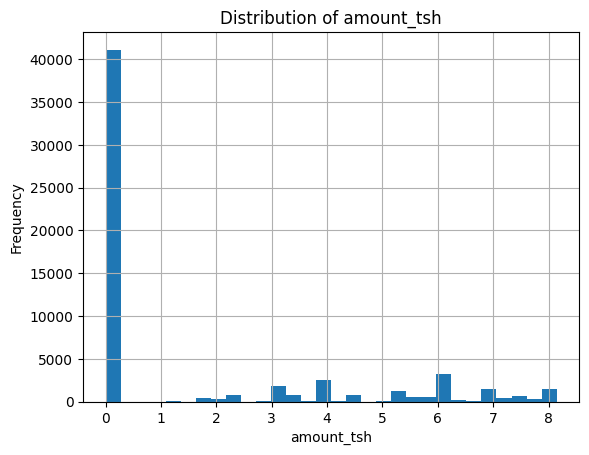

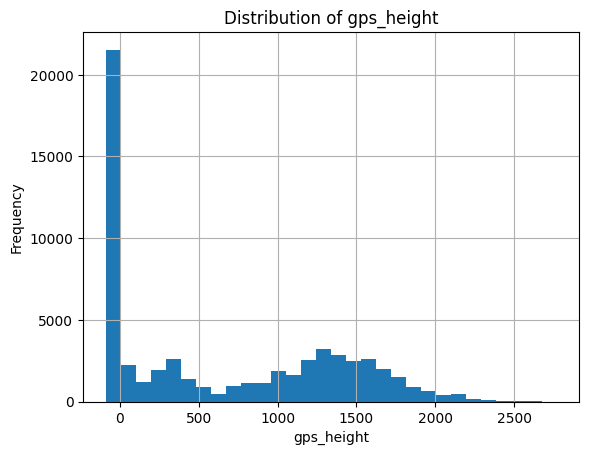

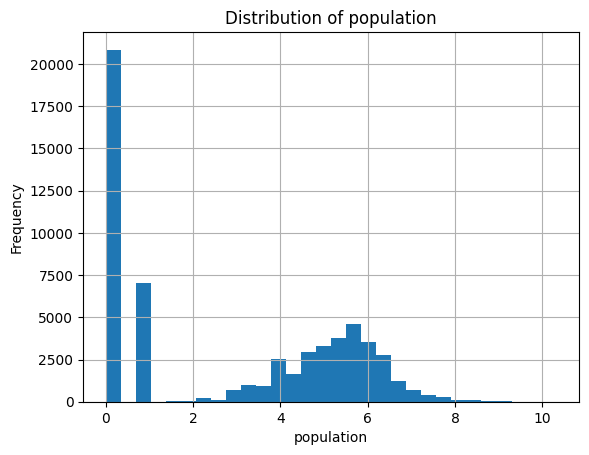

In [31]:
plot_numeric_distributions(df_clean)


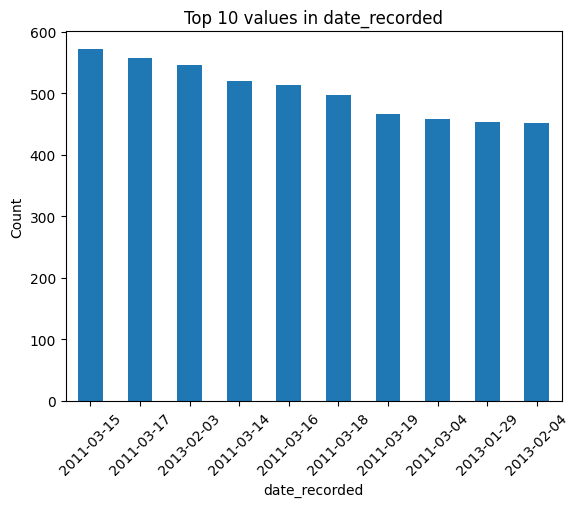

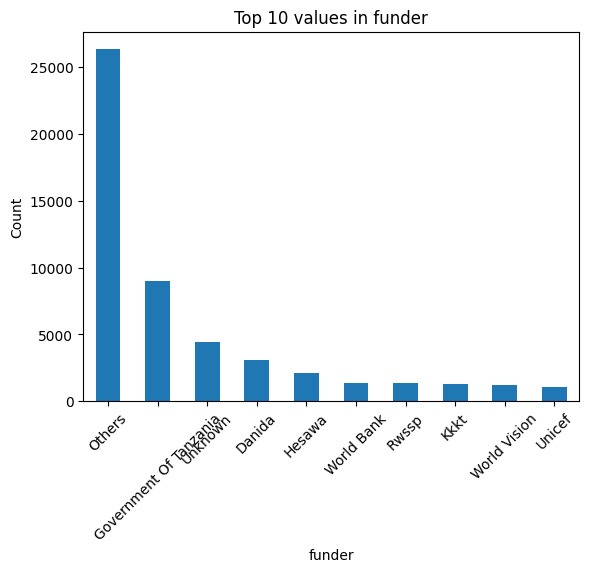

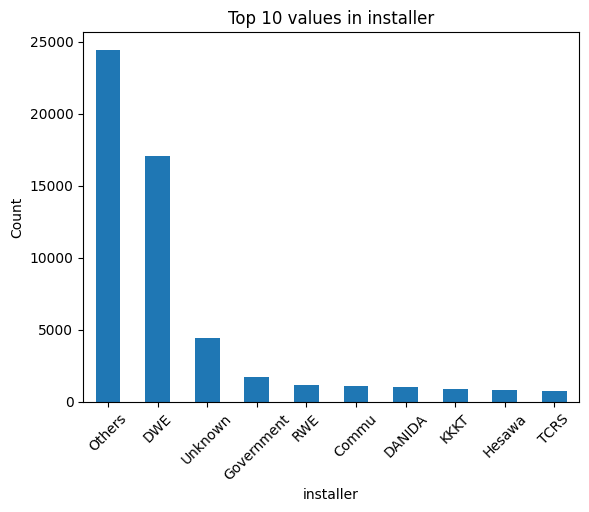

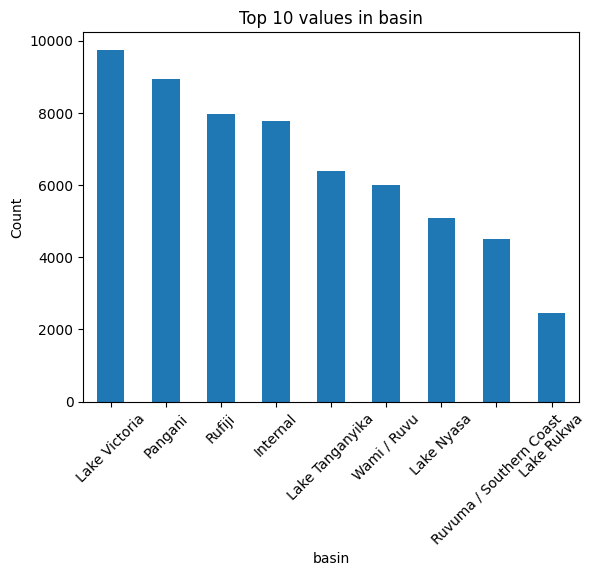

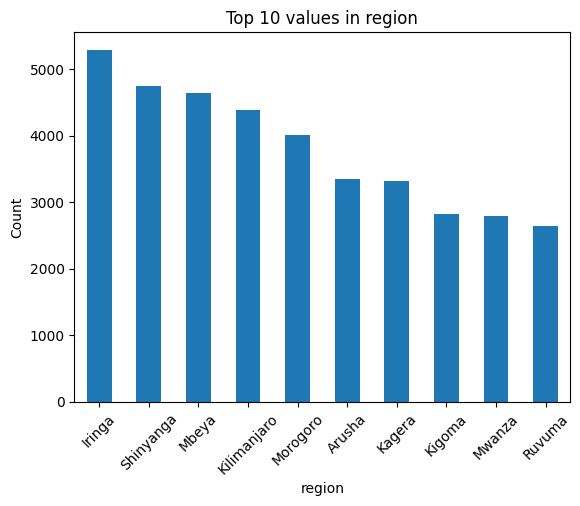

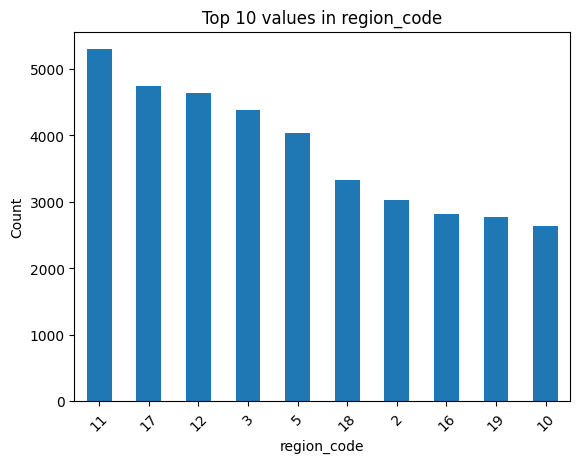

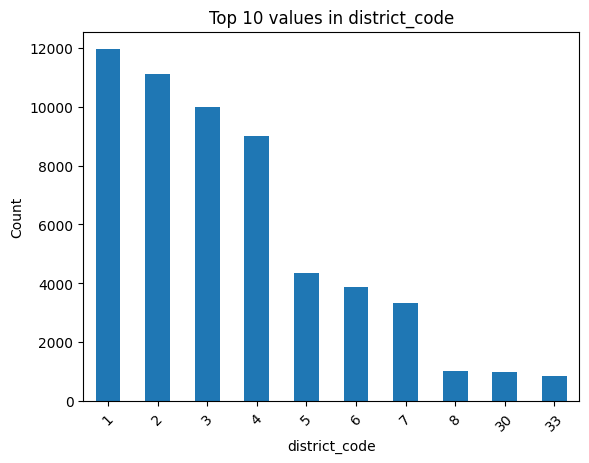

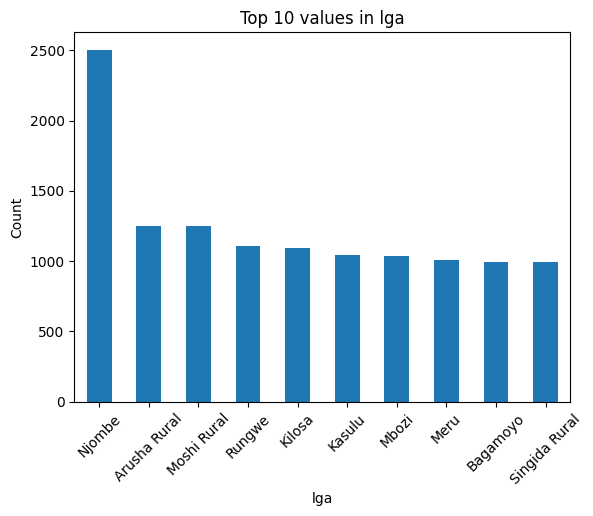

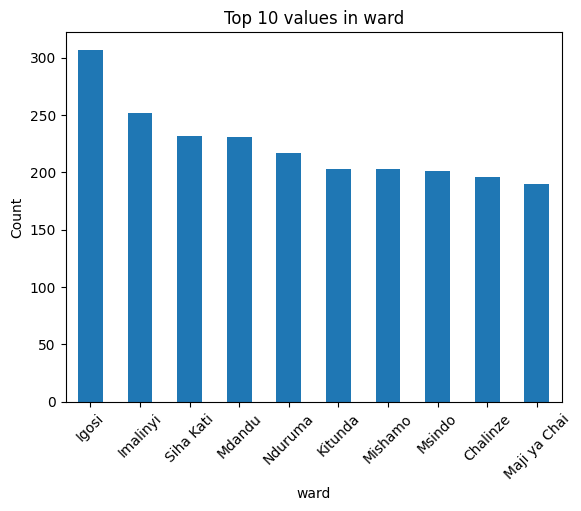

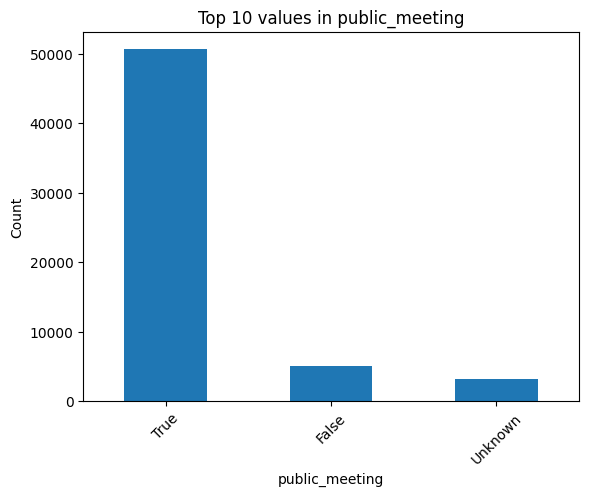

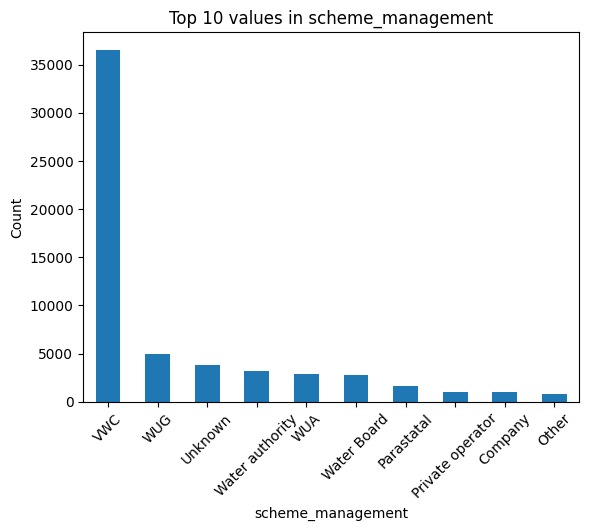

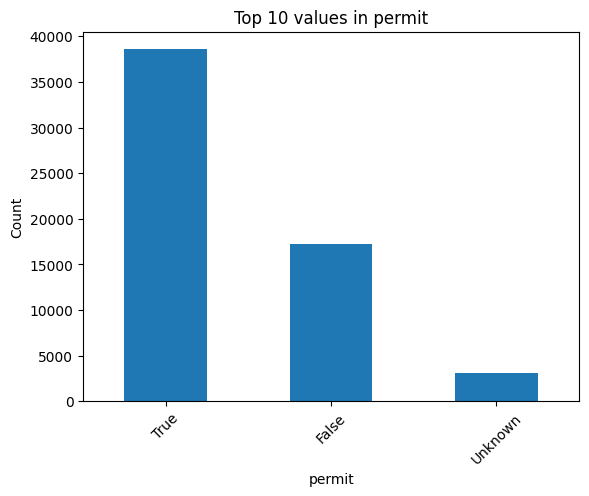

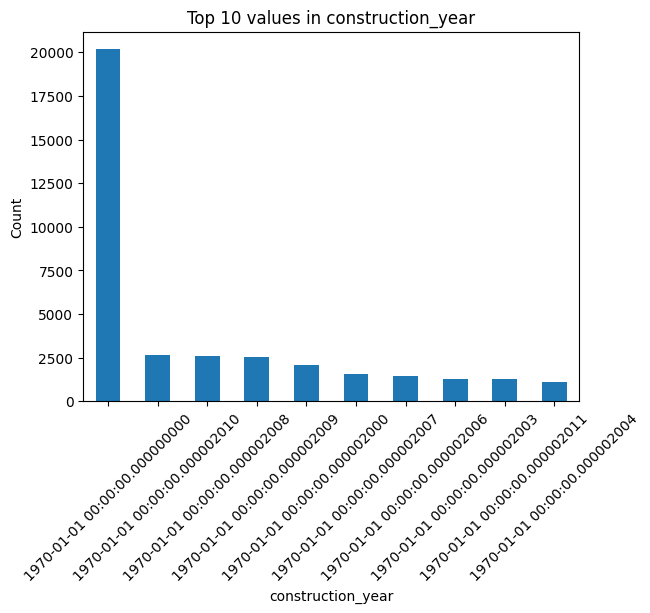

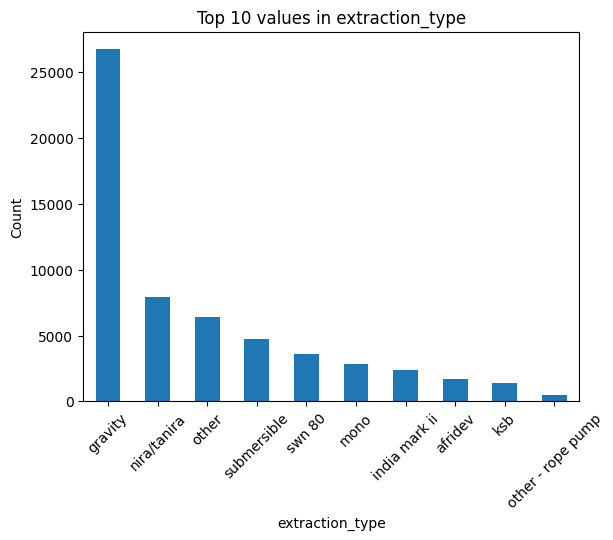

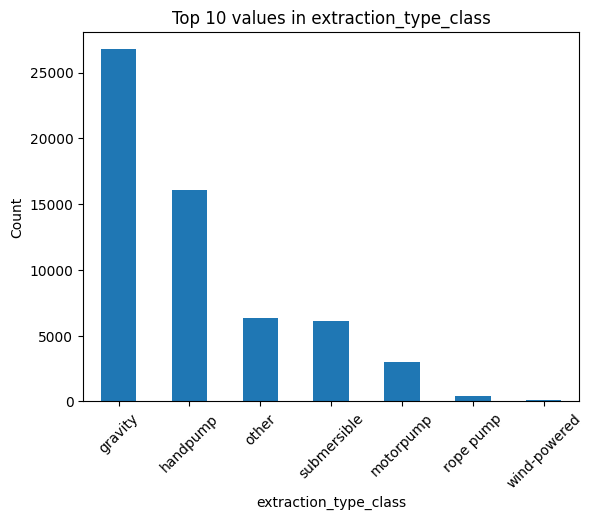

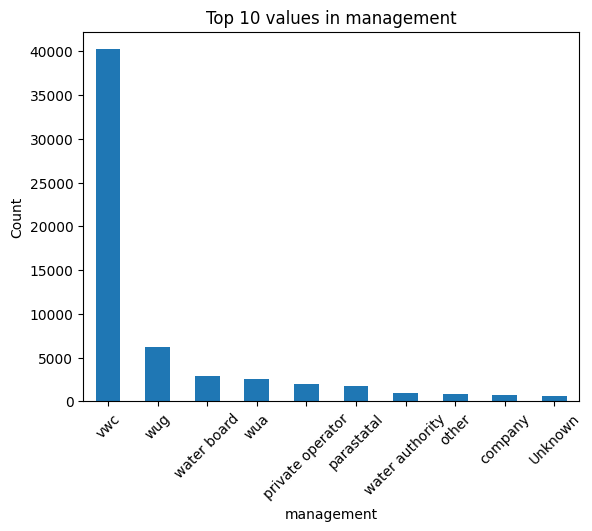

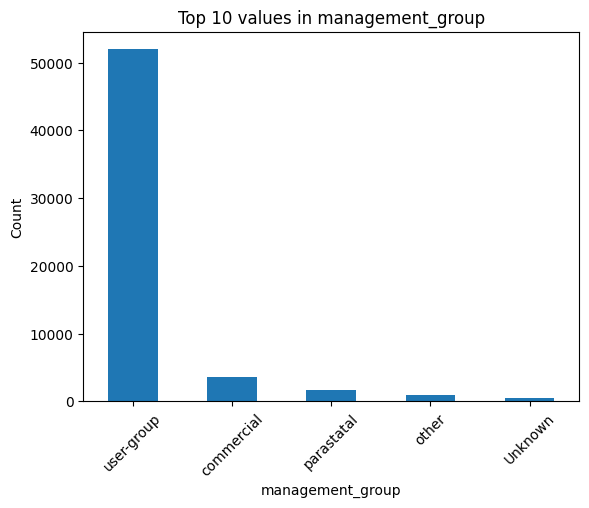

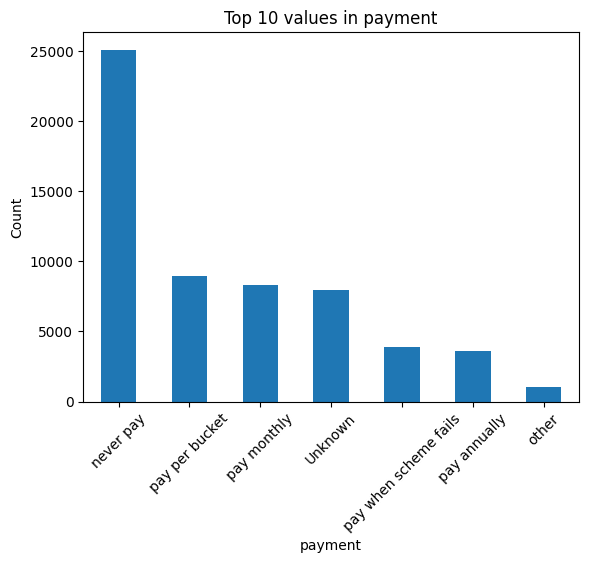

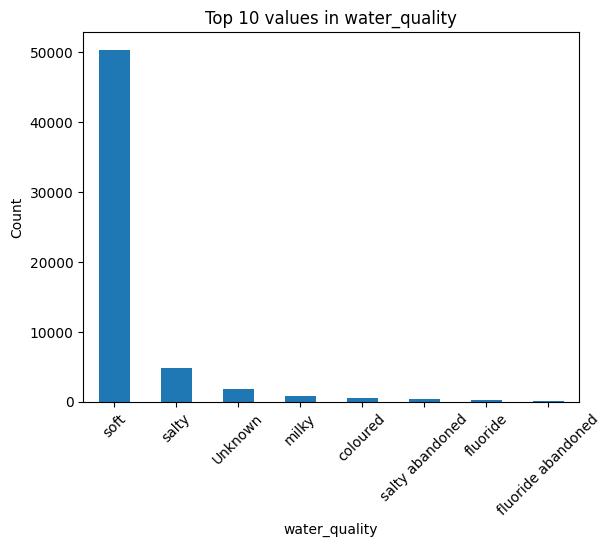

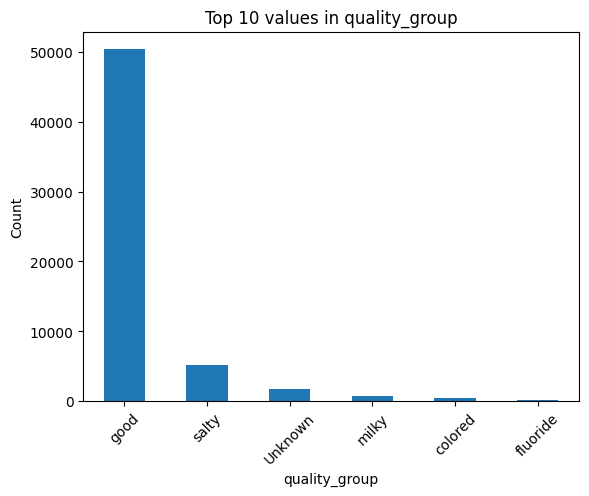

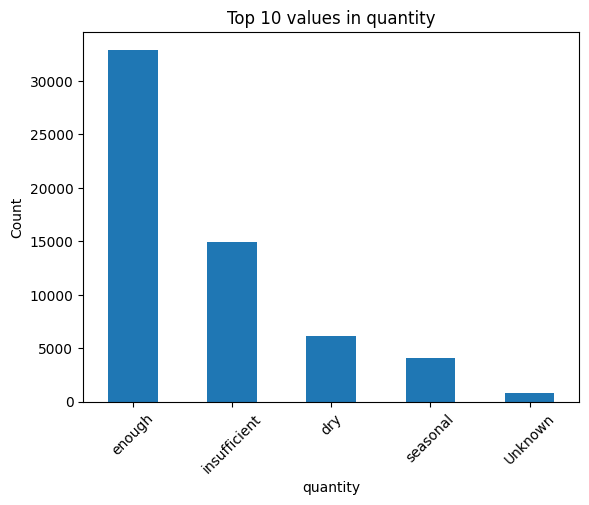

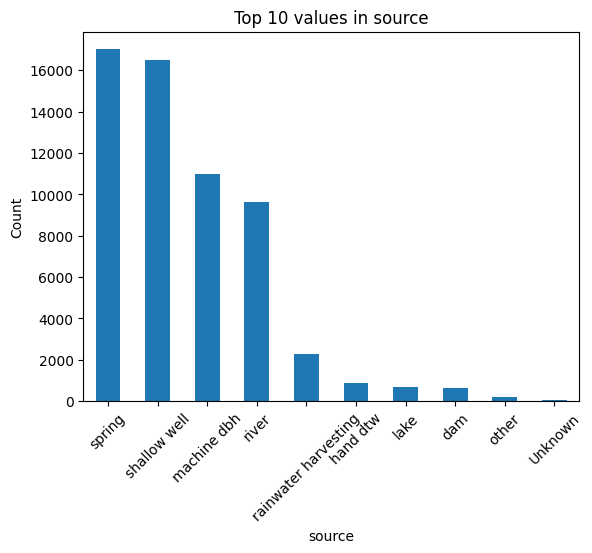

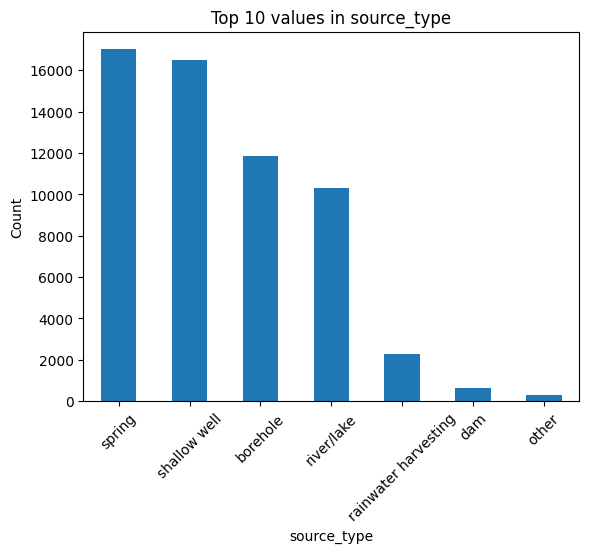

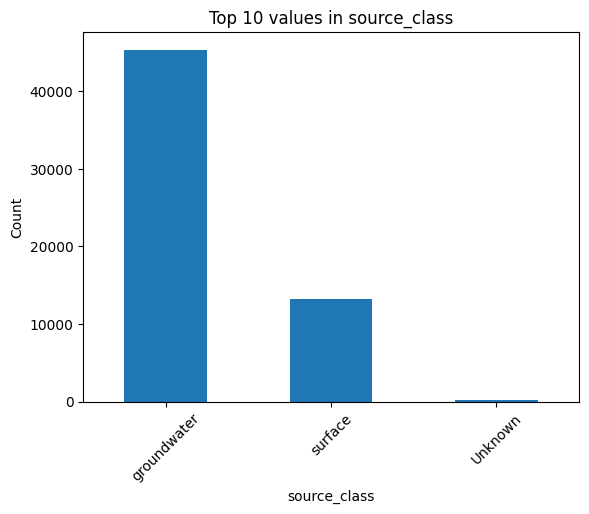

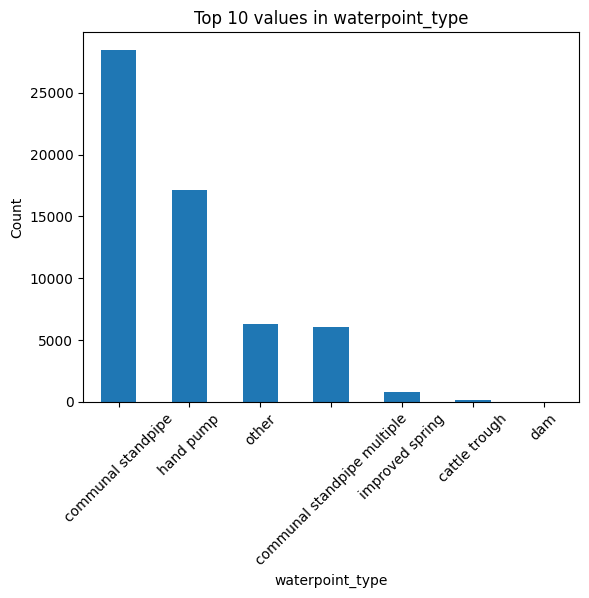

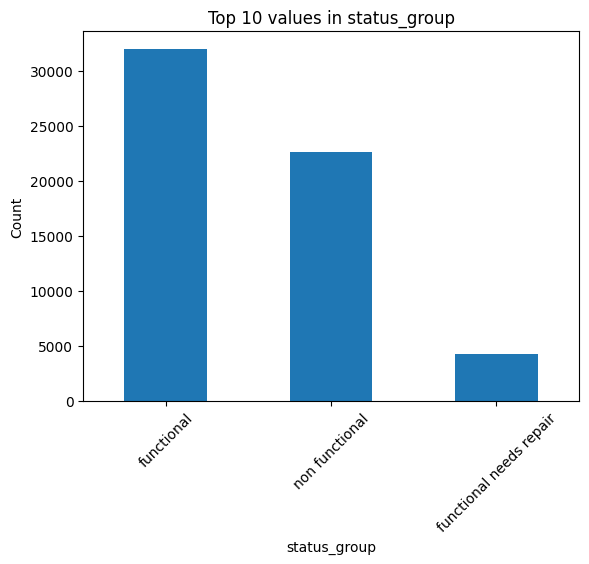

In [32]:
plot_categorical_counts(df_clean)


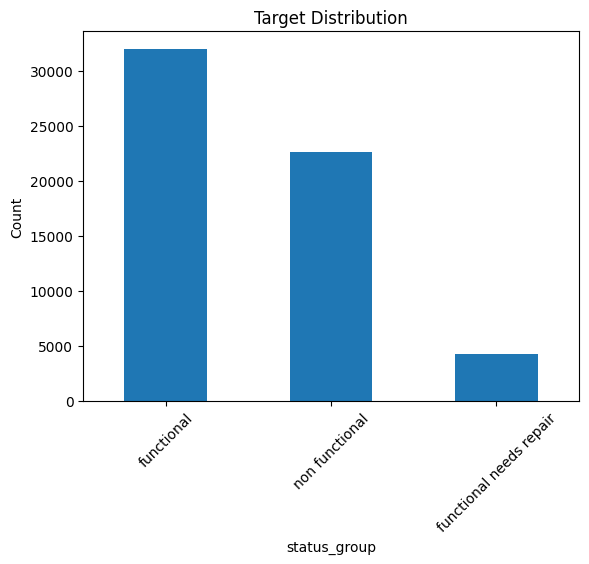

In [33]:
plot_target_distribution(df_clean, "status_group")


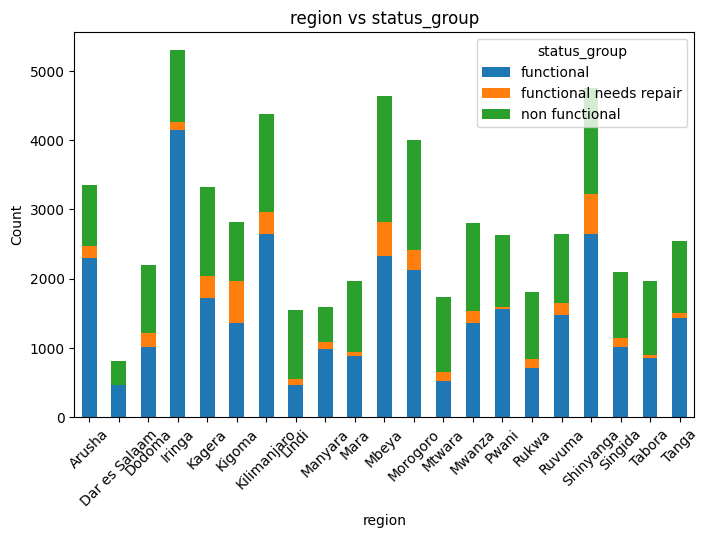

In [35]:
plot_feature_vs_target(df_clean, "region", "status_group")


In [36]:
df_clean.skew(numeric_only=True).sort_values(ascending=False)

amount_tsh    1.280146
gps_height    0.448095
population    0.124994
latitude     -0.174453
longitude    -4.608208
dtype: float64

In [37]:
skewness_report(df_clean, exclude_cols=["longitude", "latitude", "id", "region_code", "district_code"], threshold=1)

📊 Skewness Report:
            skewness status
amount_tsh      1.28   High
gps_height      0.45     OK
population      0.12     OK


,skewness,status
amount_tsh,1.28,High
gps_height,0.45,OK
population,0.12,OK


In [38]:
outlier_overview(df_clean, exclude_cols=['region_code', 'district_code','id', 'latitude', 'longitude'])

 Simple Outlier Overview:
       column  outliers  percentage (%) severity
0  amount_tsh         0             0.0      Low
1  gps_height         0             0.0      Low
2  population         0             0.0      Low


,column,outliers,percentage (%),severity
0,amount_tsh,0,0.0,Low
1,gps_height,0,0.0,Low
2,population,0,0.0,Low
